In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
df_nyt = pd.read_pickle("../data/topic modeling data/nyt.pkl")
df_other = pd.read_pickle("../data/topic modeling data/other.pkl")
"../example_articles/BERTopic/new_york_times"

In [3]:
topic_map_nyt = {
    0: "U.S. Politics & Elections",
    1: "Arts & Culture",
    2: "European Politics",
    3: "Urban Housing & NYC Life",
    4: "Latin America Politics",
    5: "Sports & Fans",
    6: "Food & Dining",
    7: "Religion & Catholic Church",
    8: "Ireland & Sectarian Conflict",
    9: "European Travel & Culture",
    10: "Public Health & COVID-19",
    11: "Media Controversy (Roseanne Barr)",
    12: "Turkey & Erdogan Politics",
    13: "Family & Personal Essays"
}

topic_map_other = {
    0: "U.S. Politics & Elections",
    1: "Arts & Entertainment",
    2: "Sports & Teams",
    3: "Literature & Writing",
    4: "Latin America Politics",
    5: "Natural Disasters & Environment",
    6: "Middle East & Conflict",
    7: "Religion & Catholic Church",
    8: "Ireland & Sectarian Conflict",
    9: "Automobile & Manufacturing",
    10: "UK Politics (Labour & EU)",
    11: "Media Controversy (Roseanne Barr)",
    12: "China & Political System",
    13: "Russia & Soviet Legacy"
}

# Map topic labels
df_nyt["BERTopic_Label"] = df_nyt["BERTopic"].map(topic_map_nyt)
df_other["BERTopic_Label"] = df_other["BERTopic"].map(topic_map_other)

In [9]:
def plot_topic_trends(df, publisher_name="Publisher", date_col="date", topic_col="BERTopic_Label",
                      normalize=True, start_year=None, figsize=(12, 8)):
    """
    Plot topic proportions over time (line chart) for a given publisher.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing date and topic label columns.
    publisher_name : str
        Title of the dataset (e.g., 'New York Times').
    date_col : str
        Column name for publication date.
    topic_col : str
        Column name for topic label.
    normalize : bool
        If True, shows proportions (share per year). If False, shows raw counts.
    start_year : int or None
        If given, filters out data before this year.
    figsize : tuple
        Chart size.
    """

    # Convert date column to datetime and extract year
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df["year"] = df[date_col].dt.year

    # Optional: filter by start year
    if start_year:
        df = df[df["year"] >= start_year]

    # Group by year and topic
    topic_trends = df.groupby(["year", topic_col]).size().reset_index(name="count")

    # Normalize to proportions if requested (✅ fixed with transform)
    if normalize:
        topic_trends["proportion"] = topic_trends["count"] / topic_trends.groupby("year")["count"].transform("sum")
    else:
        topic_trends["proportion"] = topic_trends["count"]

    # Pivot to wide format
    topic_pivot = topic_trends.pivot(index="year", columns=topic_col, values="proportion").fillna(0)
    topic_pivot = topic_pivot.sort_index()

    # Plot line chart
    plt.figure(figsize=figsize)
    topic_pivot.plot(ax=plt.gca(), linewidth=2)
    plt.title(f"Topic Trends Over Time — {publisher_name}", fontsize=15, fontweight='bold')
    plt.ylabel("Proportion of Articles" if normalize else "Number of Articles")
    plt.xlabel("Year")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


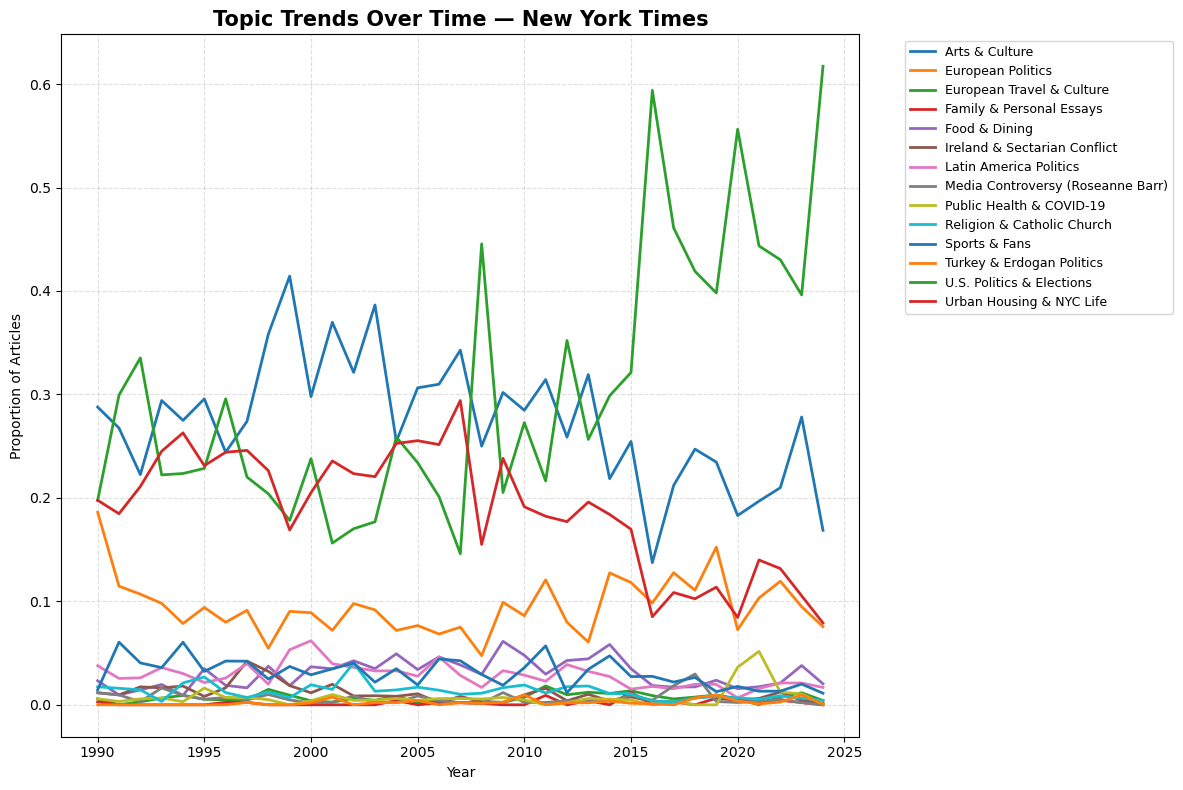

In [7]:
plot_topic_trends(df_nyt, publisher_name="New York Times", start_year=1990)


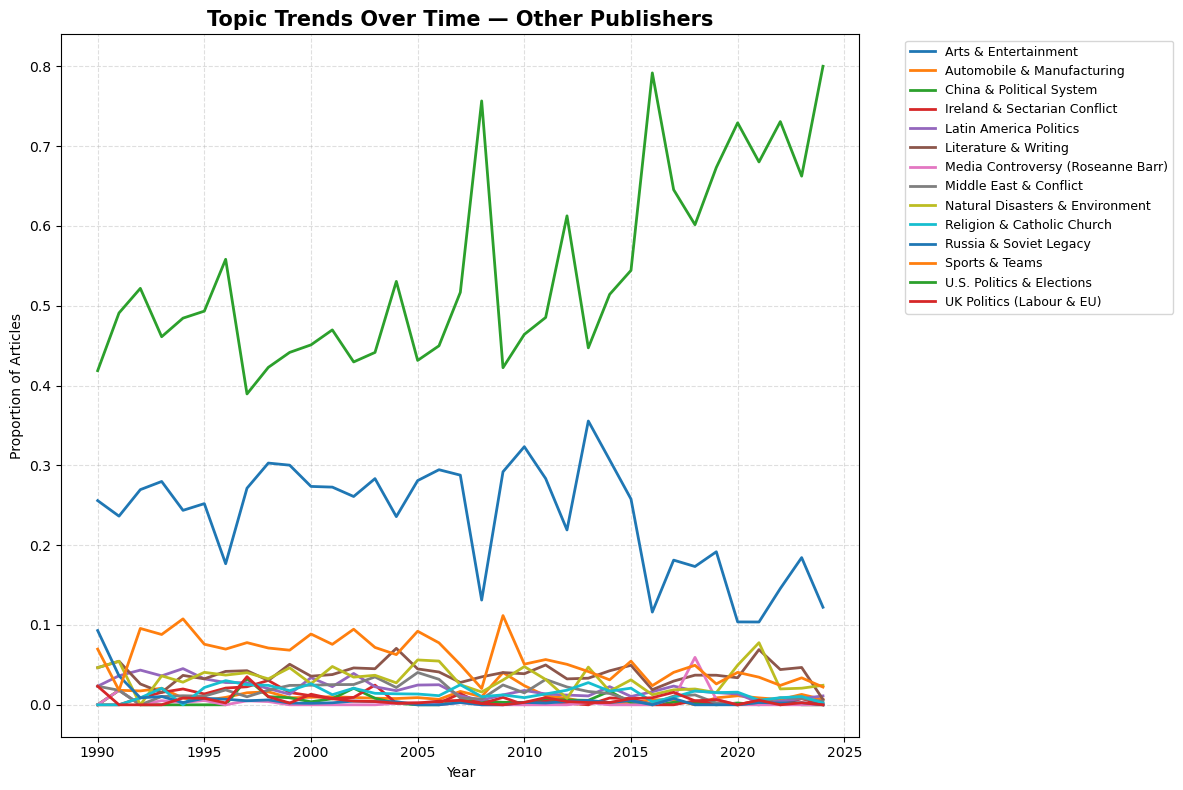

In [8]:
plot_topic_trends(df_other, publisher_name="Other Publishers", start_year=1990)

In [13]:
def clean_filename(text, max_length=200):
    """
    Clean text to make it a valid filename.
    
    Parameters
    ----------
    text : str
        Text to clean
    max_length : int
        Maximum filename length
    
    Returns
    -------
    str
        Cleaned filename
    """
    # Remove or replace invalid characters
    invalid_chars = '<>:"/\\|?*'
    for char in invalid_chars:
        text = text.replace(char, '_')
    
    # Remove leading/trailing spaces and dots
    text = text.strip('. ')
    
    # Truncate if too long
    if len(text) > max_length:
        text = text[:max_length].strip()
    
    return text

def save_article_to_file(article_row, output_path, title_col='title', body_col='body'):
    """
    Save article body content to a .txt file named after the title.
    
    Parameters
    ----------
    article_row : pd.Series
        Row from DataFrame containing article data
    output_path : Path or str
        Directory path where file should be saved
    title_col : str
        Column name for article title
    body_col : str
        Column name for article body
    """
    title = article_row[title_col]
    body = article_row[body_col]
    
    # Create safe filename from title
    filename = clean_filename(title) + '.txt'
    filepath = Path(output_path) / filename
    
    # Write body content to file
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(body)
    
    return filepath

def extract_example_articles(df, publisher_col='publisher', topic_col='BERTopic_Label', 
                            title_col='title', body_col='body', n_examples=5,
                            base_path='../example_articles/BERTopic'):
    """
    Extract example articles for each topic label, separated by publisher.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing articles with topic labels
    publisher_col : str
        Column name for publisher
    topic_col : str
        Column name for BERTopic labels
    title_col : str
        Column name for article title
    body_col : str
        Column name for article body
    n_examples : int
        Number of example articles to extract per topic
    base_path : str
        Base directory path for saving articles
    """
    base_path = Path(base_path)
    
    # Define publisher categories
    nyt_df = df[df[publisher_col] == 'New York Times'].copy()
    other_df = df[df[publisher_col] != 'New York Times'].copy()
    
    publishers_data = {
        'new_york_times': nyt_df,
        'other_publishers': other_df
    }
    
    results = {}
    
    for publisher_key, publisher_df in publishers_data.items():
        print(f"\n{'='*60}")
        print(f"Processing: {publisher_key.replace('_', ' ').title()}")
        print(f"{'='*60}")
        
        if publisher_df.empty:
            print(f"No articles found for {publisher_key}")
            continue
        
        # Create publisher directory
        publisher_path = base_path / publisher_key
        publisher_path.mkdir(parents=True, exist_ok=True)
        
        # Get unique topics
        topics = publisher_df[topic_col].dropna().unique()
        print(f"Found {len(topics)} topics")
        
        results[publisher_key] = {}
        
        for topic in topics:
            print(f"\n  Topic: {topic}")
            
            # Create topic directory
            topic_name = clean_filename(str(topic))
            topic_path = publisher_path / topic_name
            topic_path.mkdir(parents=True, exist_ok=True)
            
            # Get articles for this topic
            topic_articles = publisher_df[publisher_df[topic_col] == topic]
            
            # Sample n_examples articles (or all if fewer than n_examples)
            n_to_sample = min(n_examples, len(topic_articles))
            sampled_articles = topic_articles.sample(n=n_to_sample, random_state=42)
            
            print(f"    Extracting {n_to_sample} articles...")
            
            saved_files = []
            for idx, article in sampled_articles.iterrows():
                try:
                    filepath = save_article_to_file(article, topic_path, title_col, body_col)
                    saved_files.append(filepath)
                except Exception as e:
                    print(f"    Error saving article (index {idx}): {e}")
            
            results[publisher_key][topic] = {
                'path': topic_path,
                'n_articles': n_to_sample,
                'files': saved_files
            }
            
            print(f"    ✓ Saved {len(saved_files)} articles to: {topic_path}")
    
    return results

if __name__ == "__main__":
    results = extract_example_articles(
        df=df_other,
        publisher_col='publisher',
        topic_col='BERTopic_Label',
        title_col='title',
        body_col='body',
        n_examples=5,
        base_path='../example_articles/BERTopic'
    )



Processing: New York Times
Found 0 topics

Processing: Other Publishers
Found 14 topics

  Topic: Arts & Entertainment
    Extracting 5 articles...
    ✓ Saved 5 articles to: ../example_articles/BERTopic/other_publishers/Arts & Entertainment

  Topic: U.S. Politics & Elections
    Extracting 5 articles...
    ✓ Saved 5 articles to: ../example_articles/BERTopic/other_publishers/U.S. Politics & Elections

  Topic: Sports & Teams
    Extracting 5 articles...
    ✓ Saved 5 articles to: ../example_articles/BERTopic/other_publishers/Sports & Teams

  Topic: Automobile & Manufacturing
    Extracting 5 articles...
    ✓ Saved 5 articles to: ../example_articles/BERTopic/other_publishers/Automobile & Manufacturing

  Topic: Natural Disasters & Environment
    Extracting 5 articles...
    ✓ Saved 5 articles to: ../example_articles/BERTopic/other_publishers/Natural Disasters & Environment

  Topic: Latin America Politics
    Extracting 5 articles...
    ✓ Saved 5 articles to: ../example_articles/